In [2]:
import pandas as pd
import os

In [4]:
files = [
    r"D:\Projects\FDRL-IDS\data\raw\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    r"D:\Projects\FDRL-IDS\data\raw\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    r"D:\Projects\FDRL-IDS\data\raw\Friday-WorkingHours-Morning.pcap_ISCX.csv",
    r"D:\Projects\FDRL-IDS\data\raw\Monday-WorkingHours.pcap_ISCX.csv",
    r"D:\Projects\FDRL-IDS\data\raw\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    r"D:\Projects\FDRL-IDS\data\raw\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    r"D:\Projects\FDRL-IDS\data\raw\Tuesday-WorkingHours.pcap_ISCX.csv",
    r"D:\Projects\FDRL-IDS\data\raw\Wednesday-workingHours.pcap_ISCX.csv"
]

here this code have space problem with "Label" name

In [7]:
all_labels = []

for file in files:
    print("Reading:", os.path.basename(file))

    df = pd.read_csv(file)

    # Remove extra spaces from column names
    df.columns = df.columns.str.strip()

    # Keep only the Label column
    all_labels.append(df[["Label"]])

labels_df = pd.concat(all_labels, ignore_index=True)

print("\nTotal records:", len(labels_df))

Reading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Reading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Reading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Reading: Monday-WorkingHours.pcap_ISCX.csv
Reading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Reading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Reading: Tuesday-WorkingHours.pcap_ISCX.csv
Reading: Wednesday-workingHours.pcap_ISCX.csv

Total records: 2830743


In [6]:
for file in files:
    print("\nChecking:", os.path.basename(file))

    df = pd.read_csv(file, nrows=5)

    print("Columns:")
    print(df.columns.tolist())
    


Checking: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Columns:
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count',

In [8]:
labels_df["Label"].value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [9]:
print(labels_df["Label"].unique())

['BENIGN' 'DDoS' 'PortScan' 'Bot' 'Infiltration'
 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection' 'FTP-Patator' 'SSH-Patator' 'DoS slowloris'
 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed']


In [10]:
label_mapping = {
    "BENIGN": "BENIGN",

    "DoS Hulk": "DoS",
    "DoS GoldenEye": "DoS",
    "DoS slowloris": "DoS",
    "DoS Slowhttptest": "DoS",

    "DDoS": "DDoS",

    "FTP-Patator": "Brute Force",
    "SSH-Patator": "Brute Force",

    "Web Attack � Brute Force": "Web Attack",
    "Web Attack � XSS": "Web Attack",
    "Web Attack � Sql Injection": "Web Attack",

    "Infiltration": "Infiltration",

    "Bot": "Botnet",

    "PortScan": "Port Scan"
}

In [11]:
labels_df["Category"] = labels_df["Label"].map(label_mapping)

In [12]:
print("Unmapped records:", labels_df["Category"].isna().sum())

print("\nUnmapped labels:")
print(labels_df[labels_df["Category"].isna()]["Label"].value_counts())

Unmapped records: 11

Unmapped labels:
Label
Heartbleed    11
Name: count, dtype: int64


In [13]:
analysis_df = labels_df.dropna(subset=["Category"]).copy()

print("Original records:", len(labels_df))
print("Experimental records:", len(analysis_df))
print("Excluded records:", len(labels_df) - len(analysis_df))

Original records: 2830743
Experimental records: 2830732
Excluded records: 11


In [14]:
class_counts = analysis_df["Category"].value_counts()

print(class_counts)

Category
BENIGN          2273097
DoS              252661
Port Scan        158930
DDoS             128027
Brute Force       13835
Web Attack         2180
Botnet             1966
Infiltration         36
Name: count, dtype: int64


In [15]:
class_order = [
    "BENIGN",
    "DoS",
    "DDoS",
    "Brute Force",
    "Web Attack",
    "Infiltration",
    "Botnet",
    "Port Scan"
]

class_distribution = (
    analysis_df["Category"]
    .value_counts()
    .reindex(class_order)
    .rename_axis("Class")
    .reset_index(name="Count")
)

class_distribution["Percentage"] = (
    class_distribution["Count"] / len(analysis_df) * 100
).round(4)

class_distribution

,Class,Count,Percentage
0,BENIGN,2273097,80.3007
1,DoS,252661,8.9256
2,DDoS,128027,4.5228
3,Brute Force,13835,0.4887
4,Web Attack,2180,0.0770
5,Infiltration,36,0.0013
6,Botnet,1966,0.0695
7,Port Scan,158930,5.6144


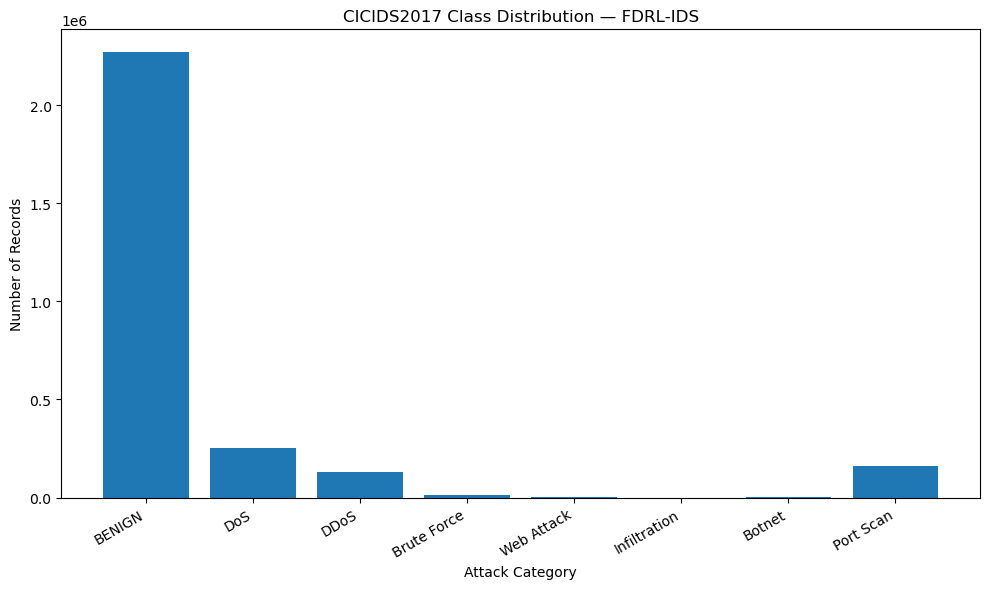

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    class_distribution["Class"],
    class_distribution["Count"]
)

plt.xlabel("Attack Category")
plt.ylabel("Number of Records")
plt.title("CICIDS2017 Class Distribution — FDRL-IDS")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../docs/figures/day10_class_distribution.png'

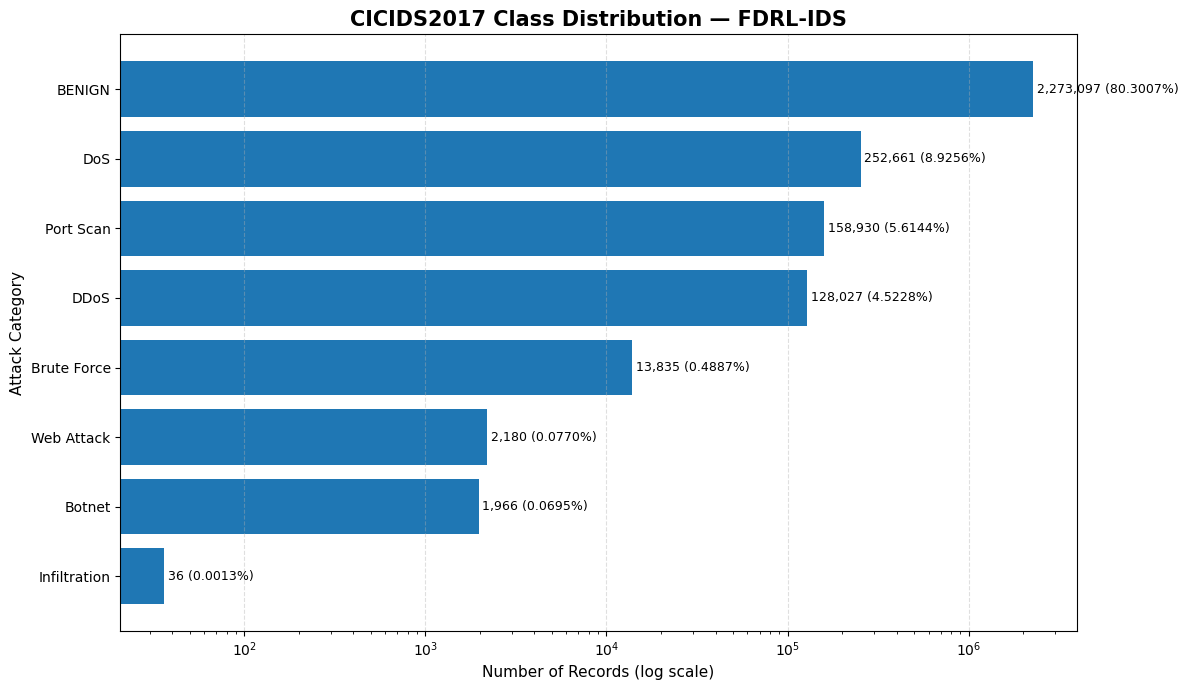

In [17]:
import matplotlib.pyplot as plt

# Sort classes by number of records
plot_df = class_distribution.sort_values("Count", ascending=True)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    plot_df["Class"],
    plot_df["Count"]
)

# Add count and percentage labels
for bar, count, percentage in zip(
    bars,
    plot_df["Count"],
    plot_df["Percentage"]
):
    plt.text(
        bar.get_width() * 1.05,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({percentage:.4f}%)",
        va="center",
        fontsize=9
    )

# Log scale is important because of extreme class imbalance
plt.xscale("log")

plt.xlabel("Number of Records (log scale)", fontsize=11)
plt.ylabel("Attack Category", fontsize=11)

plt.title(
    "CICIDS2017 Class Distribution — FDRL-IDS",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "../docs/figures/day10_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
import os

output_dir = r"D:\Projects\FDRL-IDS\docs\figures"

os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    "day10_class_distribution.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

print("Graph saved to:")
print(output_path)

Graph saved to:
D:\Projects\FDRL-IDS\docs\figures\day10_class_distribution.png


<Figure size 640x480 with 0 Axes>

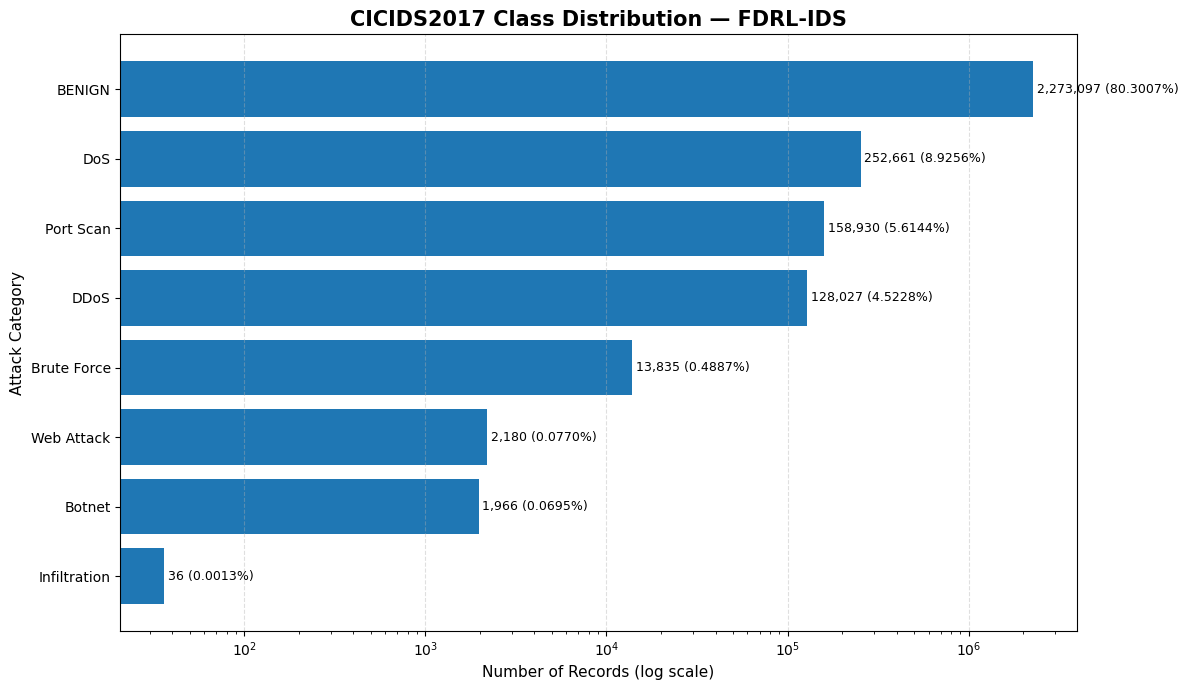

Graph saved successfully:
D:\Projects\FDRL-IDS\docs\figures\day10_class_distribution.png


In [19]:
import matplotlib.pyplot as plt
import os

# Sort classes from smallest to largest
plot_df = class_distribution.sort_values(
    "Count",
    ascending=True
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    plot_df["Class"],
    plot_df["Count"]
)

# Add count and percentage labels
for bar, count, percentage in zip(
    bars,
    plot_df["Count"],
    plot_df["Percentage"]
):
    plt.text(
        bar.get_width() * 1.05,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({percentage:.4f}%)",
        va="center",
        fontsize=9
    )

# Log scale handles the extreme class imbalance
plt.xscale("log")

plt.xlabel(
    "Number of Records (log scale)",
    fontsize=11
)

plt.ylabel(
    "Attack Category",
    fontsize=11
)

plt.title(
    "CICIDS2017 Class Distribution — FDRL-IDS",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

# Create folder automatically
output_dir = r"D:\Projects\FDRL-IDS\docs\figures"
os.makedirs(output_dir, exist_ok=True)

# Save graph
output_path = os.path.join(
    output_dir,
    "day10_class_distribution.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved successfully:")
print(output_path)